In [36]:
# importing prority_retention customers 
import pandas as pd
df = pd.read_csv('/Users/prashantsinghchauhan/Downloads/GA_/Capstone/Excel/weighted_churn.csv')
df.head()
df.shape

(7043, 8)

In [37]:
# Defining features X and target Y 
X = df[['MonthlyCharges', 'tenure', 'contract', 'InternetService']]
Y = df['churn']

In [38]:
# hot encoding categorical variables 

X_encoded = pd.get_dummies(X, columns = ['contract', 'InternetService'], drop_first= True)
X_encoded

,MonthlyCharges,tenure,contract_One year,contract_Two year,InternetService_Fiber optic,InternetService_No
0,65.60,9,True,False,False,False
1,59.90,9,False,False,False,False
2,73.90,4,False,False,True,False
3,98.00,13,False,False,True,False
4,83.90,3,False,False,True,False
...,...,...,...,...,...,...
7038,55.15,13,True,False,False,False
7039,85.10,22,False,False,True,False
7040,50.30,2,False,False,False,False
7041,67.85,67,False,True,False,False


In [39]:
# Spliting & scaling the data set for testing and training 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

# Spliting 
X_train, X_test , Y_train, Y_test = train_test_split(X_encoded, Y, test_size = 0.2, random_state = 42)

# Scaling 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [41]:
# implementing random foreset model 

from sklearn.ensemble import RandomForestClassifier

# fitting the model 
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, Y_train)

df_report = pd.DataFrame(classification_report(Y_test, Y_pred, output_dict = True)).transpose()
df_report 



,precision,recall,f1-score,support
No,0.827739,0.904440,0.864391,1036.000000
Yes,0.642599,0.477212,0.547692,373.000000
accuracy,0.791341,0.791341,0.791341,0.791341
macro avg,0.735169,0.690826,0.706042,1409.000000
weighted avg,0.778727,0.791341,0.780552,1409.000000


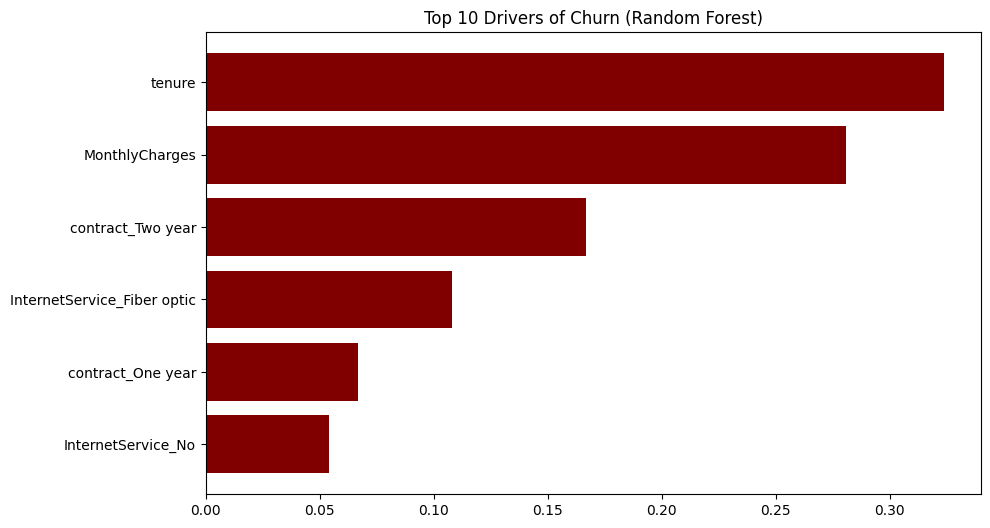

In [42]:
import matplotlib.pyplot as plt

# Developing key features 
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='maroon')
plt.gca().invert_yaxis()
plt.title('Top 10 Drivers of Churn (Random Forest)')
plt.show()